<a href="https://colab.research.google.com/github/piramid678-arch/FallGuard-AI/blob/master/%ED%94%BC%EC%A7%80%EC%BB%AC_%EA%B8%B0%EC%B4%88(DQN)_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 70.7 MB/s eta 0:00:00
Simulation finished.


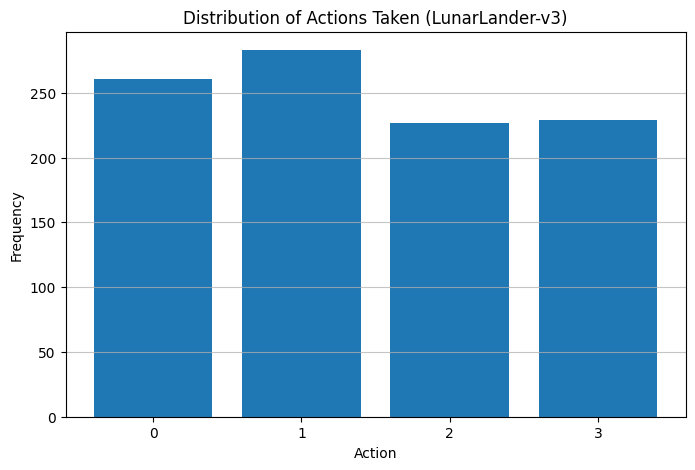

In [ ]:
!pip install swig
!pip install "gymnasium[box2d]"
import gymnasium as gym
import matplotlib.pyplot as plt

# Initialise the environment
env = gym.make("LunarLander-v3", render_mode="human")

# Reset the environment to generate the first observation
observation, info = env.reset(seed=42)

actions_taken = [] # List to store actions

for _ in range(1000):
    # this is where you would insert your policy
    action = env.action_space.sample()
    actions_taken.append(action) # Store the action

    # step (transition) through the environment with the action
    # receiving the next observation, reward and if the episode has terminated or truncated
    observation, reward, terminated, truncated, info = env.step(action)

    # If the episode has ended then we can reset to start a new episode
    if terminated or truncated:
        observation, info = env.reset()

print("Simulation finished.")

# Visualize the actions taken
plt.figure(figsize=(8, 5))
plt.hist(actions_taken, bins=range(env.action_space.n + 1), align='left', rwidth=0.8)
plt.xticks(range(env.action_space.n))
plt.xlabel("Action")
plt.ylabel("Frequency")
plt.title("Distribution of Actions Taken (LunarLander-v3)")
plt.grid(axis='y', alpha=0.75)
plt.show()

env.close()


## Deep Q-Network (DQN) 구현

LunarLander 환경에서 강화 학습을 수행하기 위해 DQN을 구현합니다. DQN은 Q-Learning과 신경망을 결합하여 복잡한 환경에서도 학습할 수 있도록 하는 알고리즘입니다.

주요 구성 요소:
- **Q-Network**: 상태를 입력받아 각 행동에 대한 Q-값을 출력하는 신경망입니다.
- **Target Q-Network**: 학습의 안정성을 위해 주기적으로 업데이트되는 Q-Network의 복사본입니다.
- **Replay Buffer**: 에이전트가 환경과 상호작용한 경험(상태, 행동, 보상, 다음 상태, 종료 여부)을 저장하고, 무작위로 샘플링하여 학습에 사용합니다.
- **Epsilon-Greedy Policy**: 탐험(exploration)과 활용(exploitation)의 균형을 맞추기 위한 정책으로, 일정 확률(`epsilon`)로 무작위 행동을 선택하고, 나머지 확률로는 Q-값이 가장 높은 행동을 선택합니다.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from collections import deque
import random

# 하이퍼파라미터 정의
STATE_SIZE = env.observation_space.shape[0]
ACTION_SIZE = env.action_space.n

GAMMA = 0.99  # 할인율
LEARNING_RATE = 0.001  # 학습률
MEM_SIZE = 100000  # 리플레이 버퍼 크기
BATCH_SIZE = 64  # 배치 크기
EPS_MAX = 1.0  # 초기 엡실론 (탐험 비율)
EPS_MIN = 0.01  # 최소 엡실론
EPS_DECAY = 0.995  # 엡실론 감쇠율
TARGET_UPDATE_FREQ = 100  # 타겟 네트워크 업데이트 주기 (에피소드 단위)


In [ ]:
# Q-Network 모델 구축 함수
def build_dqn_model():
    model = keras.Sequential([
        keras.layers.Dense(64, activation='relu', input_shape=(STATE_SIZE,)),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(ACTION_SIZE, activation='linear')
    ])
    model.compile(loss='mse', optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))
    return model


In [ ]:
# Replay Buffer 구현
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        if len(self.buffer) < batch_size:
            return [], [], [], [], [] # 충분한 데이터가 없으면 빈 리스트 반환
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return np.array(states), np.array(actions), np.array(rewards), np.array(next_states), np.array(dones)

    def __len__(self):
        return len(self.buffer)


In [ ]:
# DQN Agent 구현
class DQNAgent:
    def __init__(self):
        self.q_network = build_dqn_model()
        self.target_q_network = build_dqn_model()
        self.target_q_network.set_weights(self.q_network.get_weights())
        self.replay_buffer = ReplayBuffer(MEM_SIZE)
        self.epsilon = EPS_MAX

    def get_action(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(ACTION_SIZE) # 탐험
        q_values = self.q_network.predict(np.expand_dims(state, axis=0), verbose=0)
        return np.argmax(q_values[0]) # 활용

    def update_target_network(self):
        self.target_q_network.set_weights(self.q_network.get_weights())

    def learn(self):
        if len(self.replay_buffer) < BATCH_SIZE: # 버퍼에 충분한 데이터가 없으면 학습하지 않음
            return

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(BATCH_SIZE)

        # 현재 Q-값 예측
        current_q_values = self.q_network.predict(states, verbose=0)

        # 타겟 Q-값 예측
        target_q_values_next = self.target_q_network.predict(next_states, verbose=0)
        max_target_q_values = np.amax(target_q_values_next, axis=1)

        # Q-Learning 타겟 계산
        targets = np.copy(current_q_values)
        for i in range(BATCH_SIZE):
            if dones[i]:
                targets[i][actions[i]] = rewards[i]
            else:
                targets[i][actions[i]] = rewards[i] + GAMMA * max_target_q_values[i]

        # Q-Network 학습
        self.q_network.train_on_batch(states, targets)

        # 엡실론 감쇠
        if self.epsilon > EPS_MIN:
            self.epsilon *= EPS_DECAY


In [ ]:
# 에이전트 생성
agent = DQNAgent()

# 학습 설정
EPISODES = 500  # 에피소드 수
episode_rewards = []

# 환경 재설정
env.reset(seed=42) # 시드 고정으로 결과 재현성 확보

print("DQN 학습 시작...")

for e in range(EPISODES):
    state, _ = env.reset()
    state = np.reshape(state, [1, STATE_SIZE])
    done = False
    episode_reward = 0
    step_count = 0

    while not done:
        action = agent.get_action(state[0])
        next_state, reward, terminated, truncated, _ = env.step(action)
        next_state = np.reshape(next_state, [1, STATE_SIZE])
        done = terminated or truncated

        agent.replay_buffer.add(state[0], action, reward, next_state[0], done)
        agent.learn()

        state = next_state
        episode_reward += reward
        step_count += 1

        if done:
            episode_rewards.append(episode_reward)
            print(f"에피소드: {e+1}/{EPISODES}, 점수: {episode_reward:.2f}, 엡실론: {agent.epsilon:.2f}, 스텝: {step_count}")
            break

    if (e + 1) % TARGET_UPDATE_FREQ == 0:
        agent.update_target_network()
        print(f"--- 타겟 네트워크 업데이트 완료 (에피소드 {e+1}) ---")

env.close()
print("DQN 학습 완료.")


In [ ]:
# 학습 결과 시각화
plt.figure(figsize=(12, 6))
plt.plot(episode_rewards)
plt.xlabel("에피소드")
plt.ylabel("총 보상")
plt.title("DQN 학습 과정 (에피소드별 총 보상)")
plt.grid(True)
plt.show()


시뮬레이션 완료.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46108 (\N{HANGUL SYLLABLE DOEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

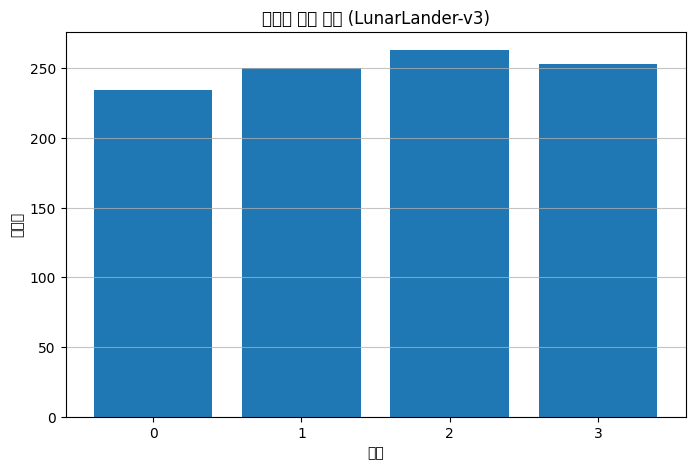

In [ ]:
!pip install swig
!pip install "gymnasium[box2d]"
import gymnasium as gym
import matplotlib.pyplot as plt

# Initialise the environment
env = gym.make("LunarLander-v3", render_mode="human")

# Reset the environment to generate the first observation
observation, info = env.reset(seed=42)

actions_taken = [] # 행동을 저장할 목록

for _ in range(1000):
    # 이 부분에 정책을 삽입합니다.
    action = env.action_space.sample()
    actions_taken.append(action) # 행동 저장

    # 행동을 통해 환경을 단계별로 진행(전환)하고,
    # 다음 관찰, 보상, 에피소드 종료 여부 또는 중단 여부를 받습니다.
    observation, reward, terminated, truncated, info = env.step(action)

    # 에피소드가 종료되거나 중단되면 새 에피소드를 시작하기 위해 재설정할 수 있습니다.
    if terminated or truncated:
        observation, info = env.reset()

print("시뮬레이션 완료.")

# 수행된 행동 시각화
plt.figure(figsize=(8, 5))
plt.hist(actions_taken, bins=range(env.action_space.n + 1), align='left', rwidth=0.8)
plt.xticks(range(env.action_space.n))
plt.xlabel("행동")
plt.ylabel("빈도수")
plt.title("수행된 행동 분포 (LunarLander-v3)")
plt.grid(axis='y', alpha=0.75)
plt.show()

env.close()

In [ ]:
!pip install swig
!pip install "gymnasium[box2d]"
import gymnasium as gym
import matplotlib.pyplot as plt

# Initialise the environment
env = gym.make("LunarLander-v3", render_mode="human")

# Reset the environment to generate the first observation
observation, info = env.reset(seed=42)

actions_taken = [] # List to store actions

for _ in range(1000):
    # this is where you would insert your policy
    action = env.action_space.sample()
    actions_taken.append(action) # Store the action

    # step (transition) through the environment with the action
    # receiving the next observation, reward and if the episode has terminated or truncated
    observation, reward, terminated, truncated, info = env.step(action)

    # If the episode has ended then we can reset to start a new episode
    if terminated or truncated:
        observation, info = env.reset()

print("Simulation finished.")

# Visualize the actions taken
plt.figure(figsize=(8, 5))
plt.hist(actions_taken, bins=range(env.action_space.n + 1), align='left', rwidth=0.8)
plt.xticks(range(env.action_space.n))
plt.xlabel("Action")
plt.ylabel("Frequency")
plt.title("Distribution of Actions Taken (LunarLander-v3)")
plt.grid(axis='y', alpha=0.75)
plt.show()

env.close()